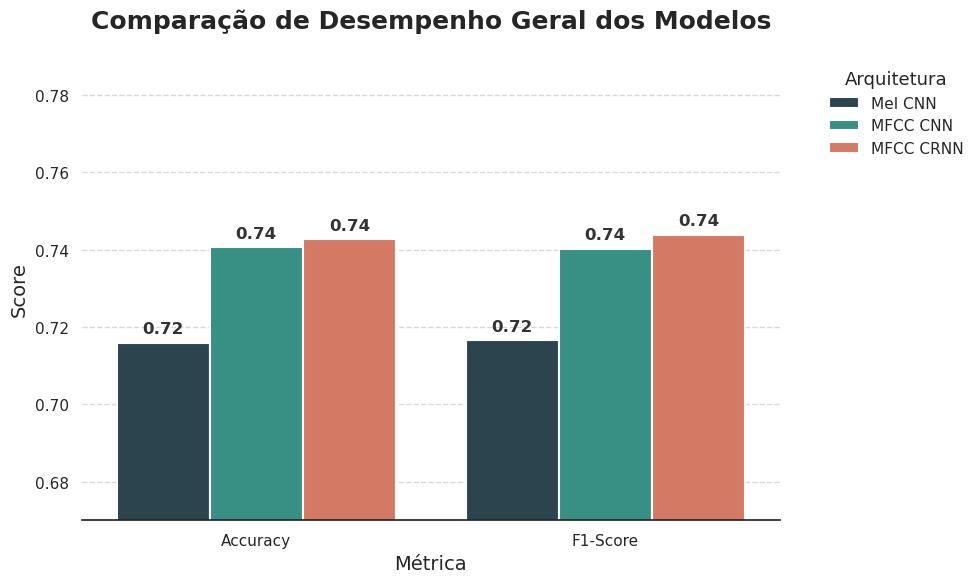

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('results.csv')

df_acc = df[df['Class/Metric'] == 'accuracy'][['Model', 'precision']].rename(columns={'precision': 'Accuracy'})
df_f1 = df[df['Class/Metric'] == 'weighted avg'][['Model', 'f1-score']].rename(columns={'f1-score': 'F1-Score'})

df_gerais = pd.merge(df_acc, df_f1, on='Model')
df_gerais_melt = df_gerais.melt(id_vars='Model', var_name='Metric', value_name='Score')

sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
plt.rcParams.update({
    'font.size': 12, 
    'axes.titlesize': 18, 
    'axes.labelsize': 14,
    'figure.autolayout': True
})

fig, ax = plt.subplots(figsize=(10, 6))

cores_customizadas = ['#264653', '#2a9d8f', '#e76f51']

sns.barplot(
    data=df_gerais_melt, 
    x='Metric', 
    y='Score', 
    hue='Model', 
    palette=cores_customizadas, 
    ax=ax,
    edgecolor='white',
    linewidth=1.5
)

sns.despine(left=True, bottom=False)

ax.yaxis.grid(True, linestyle='--', color='gray', alpha=0.3)
ax.set_axisbelow(True)

ymin = max(0, round(df_gerais_melt['Score'].min() - 0.05, 2))
ymax = min(1.0, round(df_gerais_melt['Score'].max() + 0.05, 2))
ax.set_ylim(ymin, ymax)

ax.set_title('Comparação de Desempenho Geral dos Modelos', fontweight='bold', pad=20)
ax.set_ylabel('Score')
ax.set_xlabel('Métrica')

for p in ax.patches:
    ax.annotate(
        format(p.get_height(), '.2f'), 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', va='center', 
        xytext=(0, 10), 
        textcoords='offset points',
        fontsize=12,
        fontweight='bold',
        color='#333333'
    )

plt.legend(
    title='Arquitetura',
    title_fontsize='13',
    bbox_to_anchor=(1.05, 1), 
    loc='upper left',
    frameon=False
)

plt.show()